In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [2]:
df_map = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df_map.shape)


Shape inicial: (1678326, 48)


In [3]:
df_map = df_map.copy()

In [4]:
# import pandas as pd
# import numpy as np
# import folium
# from folium.plugins import MarkerCluster
# from datetime import datetime

# # =============================
# # 1️⃣ Limpeza e Padronização (O Pulo do Gato)
# # =============================


# # Função para garantir que a BR seja uma string limpa (ex: "116")
# def limpar_br(df):
#     return df["br"].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# df_map["br"] = limpar_br(df_map)

# # Limpeza de coordenadas e KM
# cols = ["latitude", "longitude", "km"]
# for col in cols:
#     df_map[col] = pd.to_numeric(df_map[col].astype(str).str.replace(",", "."), errors="coerce")

# df_map = df_map.dropna(subset=["latitude", "longitude", "km"])
# df_map["km_bin"] = (df_map["km"] // 5) * 5

# # =============================
# # 2️⃣ Agregação
# # =============================

# # Cálculo de severidade no DF original
# df_map["severity_index"] = (4 * df_map["mortos"] + 2 * df_map["feridos_graves"] + 1 * df_map["feridos_leves"])

# df_segmento = df_map.groupby(["br", "km_bin"]).agg(
#     severity_index=("severity_index", "mean"),
#     n_acidentes=("severity_index", "count"),
#     total_mortos=("mortos", "sum"),
#     total_feridos_graves=("feridos_graves", "sum"),
#     total_feridos_leves=("feridos_leves", "sum")
# ).reset_index()

# df_segmento["risk_score"] = df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"])
# df_segmento["taxa_mortalidade"] = df_segmento["total_mortos"] / df_segmento["n_acidentes"]

# def classificar_gravidade(row):
#     if row["total_mortos"] > 0: return "Acidente com mortos"
#     if (row["total_feridos_graves"] > 0) or (row["total_feridos_leves"] > 0): return "Sinistro de média gravidade"
#     return "Sinistro sem gravidade"

# df_segmento["gravidade"] = df_segmento.apply(classificar_gravidade, axis=1)

# # =============================
# # 3️⃣ Mapa e Plotagem
# # =============================

# m = folium.Map(
#     location=[df_map["latitude"].median(), df_map["longitude"].median()],
#     zoom_start=6,
#     #tiles="CartoDB positron" # Evita o erro 403 Access Blocked
# )

# # Camadas
# layers = {
#     "Acidente com mortos": MarkerCluster(name="🔴 Acidente com mortos").add_to(m),
#     "Sinistro de média gravidade": MarkerCluster(name="🟠 Média gravidade").add_to(m),
#     "Sinistro sem gravidade": MarkerCluster(name="🟢 Sem gravidade").add_to(m)
# }

# segmentos_grupo = df_map.groupby(["br", "km_bin"])

# for _, row in df_segmento.iterrows():
#     try:
#         # Busca o grupo usando as chaves limpas
#         grupo = segmentos_grupo.get_group((row["br"], row["km_bin"]))
#         lat, lon = grupo["latitude"].median(), grupo["longitude"].median()
#     except KeyError:
#         continue # Se não achar, pula

#     # Define cor
#     cor = "red" if row["gravidade"] == "Acidente com mortos" else "orange" if row["gravidade"] == "Sinistro de média gravidade" else "green"

#     # Popup
#     veiculos = grupo["tipo_veiculo"].value_counts().head(3)
#     veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

#     popup_html = f"""
#     <b>BR:</b> {row['br']} | <b>KM:</b> {row['km_bin']}<br>
#     <b>Gravidade:</b> {row['gravidade']}<br>
#     <b>Mortos:</b> {row['total_mortos']}<br>
#     <hr><b>Top Veículos:</b><br>{veiculo_txt}
#     """

#     # CircleMarker é melhor que Circle porque o tamanho é fixo em pixels
#     folium.CircleMarker(
#         location=[lat, lon],
#         radius=7 + (np.log1p(row["total_mortos"]) * 3),
#         color=cor,
#         fill=True,
#         fill_opacity=0.7,
#         popup=folium.Popup(popup_html, max_width=250)
#     ).add_to(layers[row["gravidade"]])

# folium.LayerControl().add_to(m)
# path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsGeral/mapa_risco_{datetime.now().strftime('%Y%m%d_%H%M')}.html"
# m.save(path)
# print(f"Mapa gerado com sucesso em: {path}")

In [11]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from datetime import datetime

# =============================
# 1️⃣ Limpeza e Padronização (O Pulo do Gato)
# =============================


# Função para garantir que a BR seja uma string limpa (ex: "116")
def limpar_br(df):
    return df["br"].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

df_map["br"] = limpar_br(df_map)

# =============================
# FILTRO DE RODOVIA (BR)
# =============================

br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

if br_escolhida.strip() != "":
    df_map = df_map[df_map["br"] == br_escolhida.strip()]
    print(f"Filtrando apenas BR {br_escolhida}")
else:
    print("Mostrando todas as rodovias")

if df_map.empty:
    print("Nenhum dado encontrado para essa BR.")
    exit()
# Limpeza de coordenadas e KM
cols = ["latitude", "longitude", "km"]
for col in cols:
    df_map[col] = pd.to_numeric(df_map[col].astype(str).str.replace(",", "."), errors="coerce")

df_map = df_map.dropna(subset=["latitude", "longitude", "km"])
df_map["km_bin"] = (df_map["km"] // 5) * 5

# =============================
# 2️⃣ Agregação
# =============================

# Cálculo de severidade no DF original
df_map["severity_index"] = (4 * df_map["mortos"] + 2 * df_map["feridos_graves"] + 1 * df_map["feridos_leves"])

df_segmento = df_map.groupby(["br", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    total_feridos_leves=("feridos_leves", "sum")
).reset_index()

df_segmento["risk_score"] = df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"])
df_segmento["taxa_mortalidade"] = df_segmento["total_mortos"] / df_segmento["n_acidentes"]

def classificar_gravidade(row):
    if row["total_mortos"] > 0: return "Acidente com mortos"
    if (row["total_feridos_graves"] > 0) or (row["total_feridos_leves"] > 0): return "Sinistro de média gravidade"
    return "Sinistro sem gravidade"

df_segmento["gravidade"] = df_segmento.apply(classificar_gravidade, axis=1)

# =============================
# 3️⃣ Mapa e Plotagem
# =============================

m = folium.Map(
    location=[df_map["latitude"].median(), df_map["longitude"].median()],
    zoom_start=6,
    #tiles="CartoDB positron" # Evita o erro 403 Access Blocked
)

# Camadas
layers = {
    "Acidente com mortos": MarkerCluster(name="🔴 Acidente com mortos").add_to(m),
    "Sinistro de média gravidade": MarkerCluster(name="🟠 Média gravidade").add_to(m),
    "Sinistro sem gravidade": MarkerCluster(name="🟢 Sem gravidade").add_to(m)
}

segmentos_grupo = df_map.groupby(["br", "km_bin"])

for _, row in df_segmento.iterrows():
    try:
        # Busca o grupo usando as chaves limpas
        grupo = segmentos_grupo.get_group((row["br"], row["km_bin"]))
        lat, lon = grupo["latitude"].median(), grupo["longitude"].median()
    except KeyError:
        continue # Se não achar, pula

    # Define cor
    cor = "red" if row["gravidade"] == "Acidente com mortos" else "orange" if row["gravidade"] == "Sinistro de média gravidade" else "green"

    # Popup
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    popup_html = f"""
    <b>BR:</b> {row['br']} | <b>KM:</b> {row['km_bin']}<br>
    <b>Gravidade:</b> {row['gravidade']}<br>
    <b>Total de acidentes:</b> {row['n_acidentes']}<br>
    <b>Mortos:</b> {row['total_mortos']}<br>
    <hr><b>Top Veículos:</b><br>{veiculo_txt}
    """

    # CircleMarker é melhor que Circle porque o tamanho é fixo em pixels
    folium.CircleMarker(
        location=[lat, lon],
        radius=7 + (np.log1p(row["total_mortos"]) * 3),
        color=cor,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(layers[row["gravidade"]])

folium.LayerControl().add_to(m)
path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsGeral/mapa_risco_{datetime.now().strftime('%Y%m%d_%H%M')}.html"
m.save(path)
print(f"Mapa gerado com sucesso em: {path}")

Mostrando todas as rodovias
Mapa gerado com sucesso em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsGeral/mapa_risco_20260316_1505.html


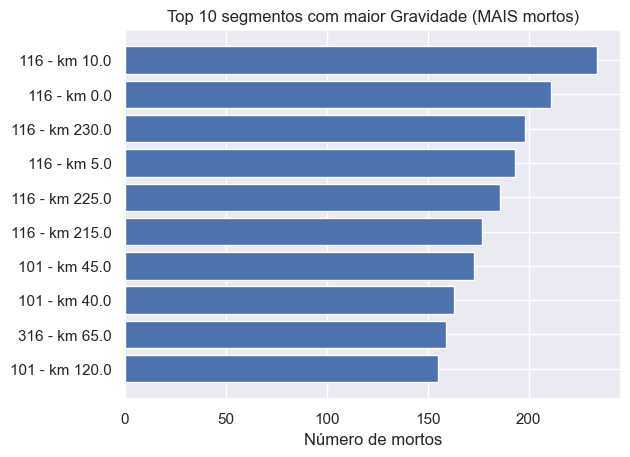

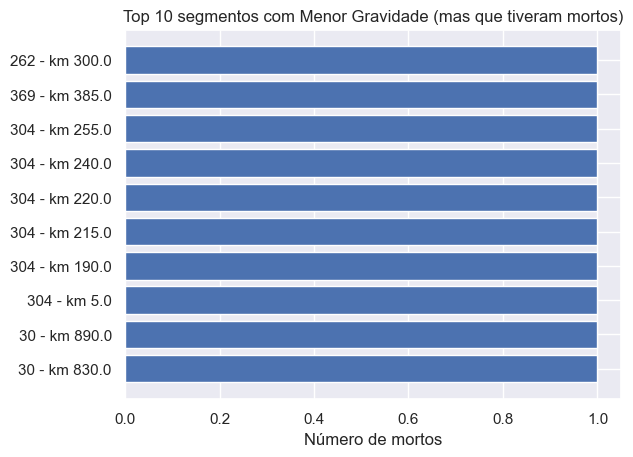

In [6]:
import matplotlib.pyplot as plt

# =============================
# 1️⃣ Filtrar apenas acidentes com mortos
# =============================
df_segmento["br"] = df_segmento["br"].astype(str)
df_mortos = df_segmento[df_segmento["gravidade"] == "Acidente com mortos"].copy()

# Ordenar por número de mortos
df_mortos = df_mortos.sort_values("total_mortos", ascending=False)

# =============================
# 2️⃣ Top 10 com mais mortos
# =============================

top10_mortos = df_mortos.head(10)

top10_mortos["segmento"] = (
    top10_mortos["br"].astype(str) + " - km " +
    top10_mortos["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    top10_mortos["segmento"],
    top10_mortos["total_mortos"]
)

plt.xlabel("Número de mortos")
plt.title("Top 10 segmentos com maior Gravidade (MAIS mortos)")
plt.gca().invert_yaxis()

plt.show()


# =============================
# 3️⃣ 10 segmentos com menos mortos
# =============================

menos_mortos = df_mortos.tail(10).sort_values("total_mortos")

menos_mortos["segmento"] = (
    menos_mortos["br"].astype(str) + " - km " +
    menos_mortos["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    menos_mortos["segmento"],
    menos_mortos["total_mortos"]
)

plt.xlabel("Número de mortos")
plt.title("Top 10 segmentos com Menor Gravidade (mas que tiveram mortos)")
plt.gca().invert_yaxis()

plt.show()

In [7]:
grupo = df_map[(df_map["br"] == "116") & (df_map["km_bin"] == 10)]

print(grupo[["latitude","longitude"]].head())

      latitude  longitude
1793 -3.860885 -38.497153
1794 -3.860885 -38.497153
1795 -3.860885 -38.497153
1796 -3.860885 -38.497153
1797 -3.860885 -38.497153


In [8]:
print(grupo[["latitude","longitude"]].mean())

latitude    -12.513622
longitude   -42.064709
dtype: float64


In [9]:
for _, row in top10_mortos.iterrows():
    chave = (row["br"], row["km_bin"])
    print(chave in segmentos_grupo.groups)

True
True
True
True
True
True
True
True
True
True


In [10]:
# =========================================================
# BLOCO DE TESTE E DIAGNÓSTICO (Rode isso no Jupyter)
# =========================================================

# 1. Garantir que as chaves de busca e o agrupamento usem o mesmo tipo (String para BR e Float para KM)
df_map["br"] = df_map["br"].astype(str).str.strip().str.replace(".0", "", regex=False)
df_segmento["br"] = df_segmento["br"].astype(str).str.strip().str.replace(".0", "", regex=False)

# Re-agrupar para garantir que a memória do pandas esteja fresca
segmentos_teste = df_map.groupby(["br", "km_bin"])

print(f"--- Diagnóstico de Dados ---")
print(f"Total de linhas em df_segmento: {len(df_segmento)}")
print(f"Exemplos de chaves no agrupamento: {list(segmentos_teste.groups.keys())[:5]}")
print("-" * 30)

encontrou_116 = False

for index, row in df_segmento.iterrows():
    br_chave = str(row["br"])
    km_chave = row["km_bin"]
    
    # Filtro para testar especificamente a 116
    if "116" in br_chave:
        encontrou_116 = True
        try:
            # Tenta buscar o grupo
            segment = segmentos_teste.get_group((br_chave, km_chave))
            # Se chegar aqui, deu certo
            # print(f"Sucesso: BR-{br_chave} KM {km_chave} encontrada. {len(segment)} registros.")
        except KeyError:
            print(f"❌ ERRO DE BUSCA: BR-{br_chave} KM {km_chave} NÃO encontrada!")
            print(f"   -> Tipo da chave BR: {type(br_chave)} | Valor: '{br_chave}'")
            print(f"   -> Tipo da chave KM: {type(km_chave)} | Valor: {km_chave}")
            
            # Verificar se a BR-116 existe com outro nome no grupo
            brs_existentes = df_map["br"].unique()
            if br_chave not in brs_existentes:
                print(f"   -> Alerta: '{br_chave}' não existe no df_map original. Disponíveis: {brs_existentes[:5]}")
            break # Para no primeiro erro para você analisar

if not encontrou_116:
    print("⚠️ A BR-116 sequer foi encontrada no seu dataframe 'df_segmento'. Verifique os filtros anteriores.")

--- Diagnóstico de Dados ---
Total de linhas em df_segmento: 7524
Exemplos de chaves no agrupamento: [('10', 0.0), ('10', 5.0), ('10', 10.0), ('10', 15.0), ('10', 20.0)]
------------------------------
